In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

import os
import tarfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
import zipfile
from tqdm import tqdm
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class FacadesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.img_dir = os.path.join(root_dir, "facades", "train")
        self.img_files = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        image = Image.open(img_path).convert('RGB')

        # Split concatenated image (input|target)
        w, h = image.size
        input_img = image.crop((0, 0, w//2, h))
        target_img = image.crop((w//2, 0, w, h))

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img


In [ ]:
def download_dataset():
    if not os.path.exists("facades"):
        print("Downloading dataset using wget...")
        # Remove any previous corrupted file
        if os.path.exists("facades.tar.gz"):
            os.remove("facades.tar.gz")

        # Download using wget
        !wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz

        # Extract safely
        try:
            with tarfile.open("facades.tar.gz", "r:gz") as tar:
                tar.extractall(".")
            os.remove("facades.tar.gz")
            print("✅ Dataset downloaded and extracted!")
        except tarfile.ReadError:
            print("❌ Still not a valid tar.gz — please check the network or retry.")
    else:
        print("✅ Dataset already exists.")

# Run it
download_dataset()

✅ Dataset already exists.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = FacadesDataset(".", transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f"Dataset size: {len(dataset)}")

Dataset size: 258


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        # Encoder
        self.e1 = nn.Conv2d(3, 64, 4, 2, 1)
        self.e2 = self._block(64, 128)
        self.e3 = self._block(128, 256)
        self.e4 = self._block(256, 512, dropout=True)
        self.e5 = self._block(512, 512, dropout=True)
        self.e6 = self._block(512, 512, dropout=True)
        self.e7 = self._block(512, 512, dropout=True)
        self.e8 = nn.Conv2d(512, 512, 4, 2, 1)

        # Decoder
        self.d1 = self._upblock(512, 512, dropout=True)
        self.d2 = self._upblock(1024, 512, dropout=True)
        self.d3 = self._upblock(1024, 512, dropout=True)
        self.d4 = self._upblock(1024, 512)
        self.d5 = self._upblock(1024, 256)
        self.d6 = self._upblock(512, 128)
        self.d7 = self._upblock(256, 64)
        self.d8 = nn.ConvTranspose2d(128, 3, 4, 2, 1)

        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.2)

    def _block(self, in_c, out_c, dropout=False):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2)]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def _upblock(self, in_c, out_c, dropout=False):
        layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.ReLU()]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.leaky_relu(self.e1(x))
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        e8 = self.e8(e7)

        # Decoder with skip connections
        d1 = self.d1(e8)
        d2 = self.d2(torch.cat([d1, e7], 1))
        d3 = self.d3(torch.cat([d2, e6], 1))
        d4 = self.d4(torch.cat([d3, e5], 1))
        d5 = self.d5(torch.cat([d4, e4], 1))
        d6 = self.d6(torch.cat([d5, e3], 1))
        d7 = self.d7(torch.cat([d6, e2], 1))
        d8 = self.d8(torch.cat([d7, e1], 1))

        return self.tanh(d8)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, input_img, target_img):
        x = torch.cat([input_img, target_img], 1)
        return self.model(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

In [ ]:
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


Epoch 10: 100%|██████████| 17/17 [00:10<00:00,  1.65it/s]


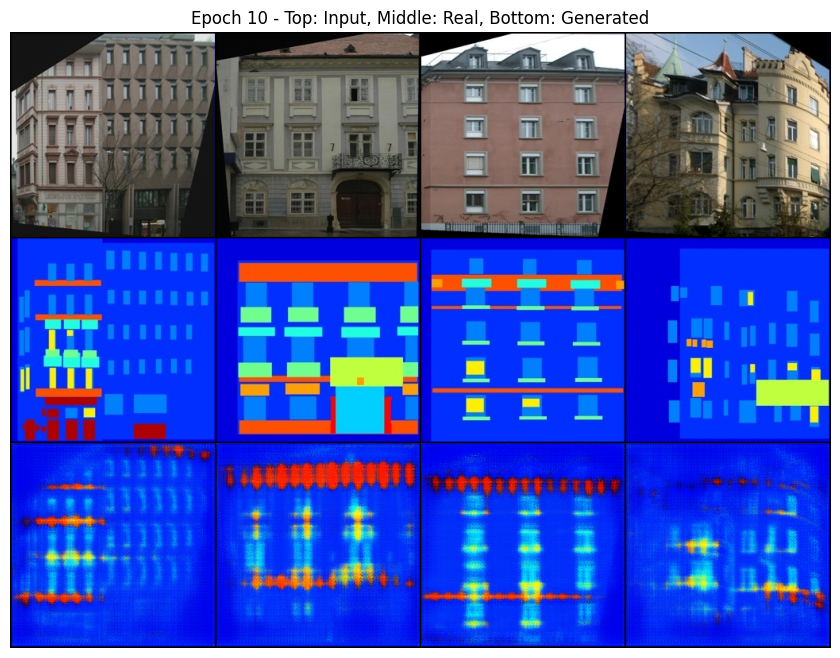

Epoch 10 - D Loss: 0.0464, G Loss: 59.3377


Epoch 20: 100%|██████████| 17/17 [00:10<00:00,  1.63it/s]


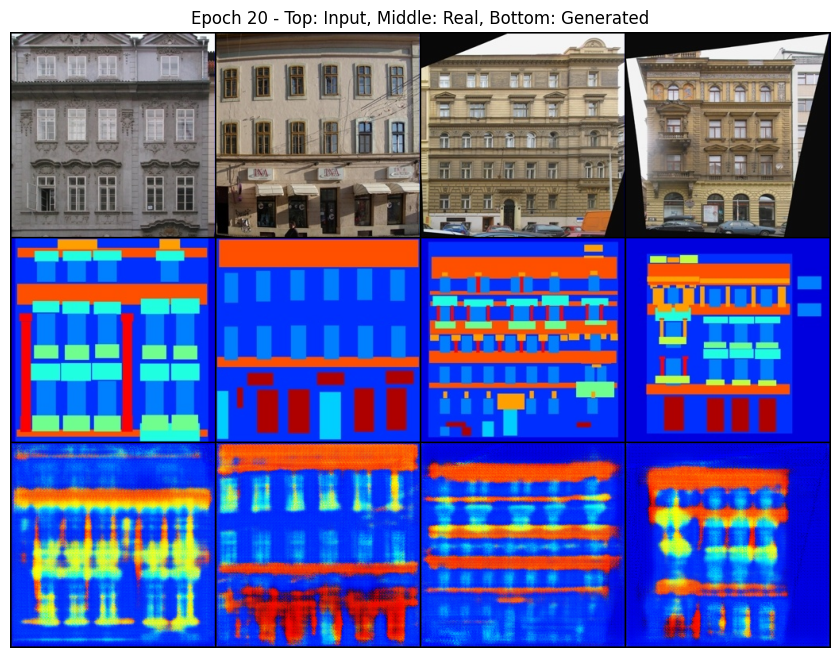

Epoch 20 - D Loss: 0.3428, G Loss: 33.4453


Epoch 30: 100%|██████████| 17/17 [00:10<00:00,  1.63it/s]


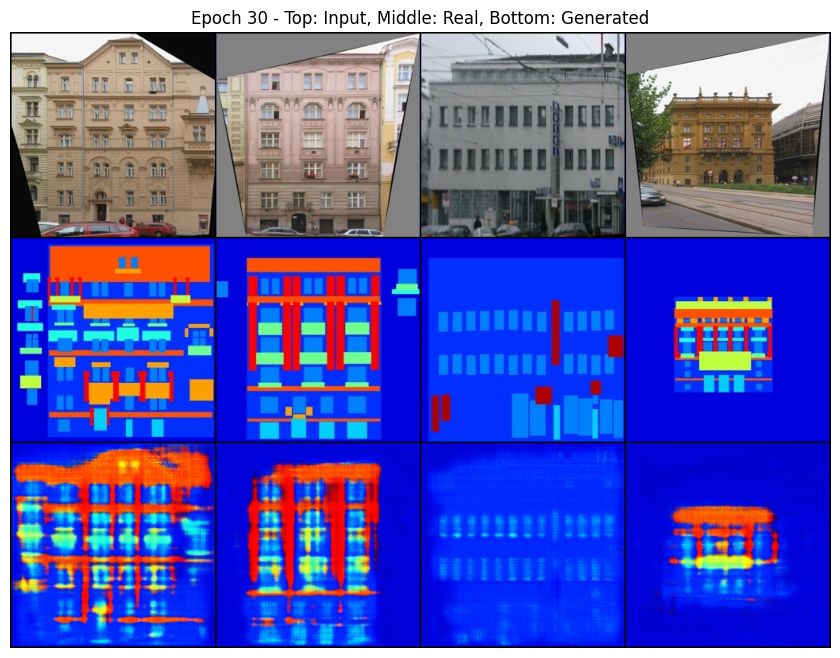

Epoch 30 - D Loss: 0.7508, G Loss: 31.0925


Epoch 40: 100%|██████████| 17/17 [00:10<00:00,  1.63it/s]


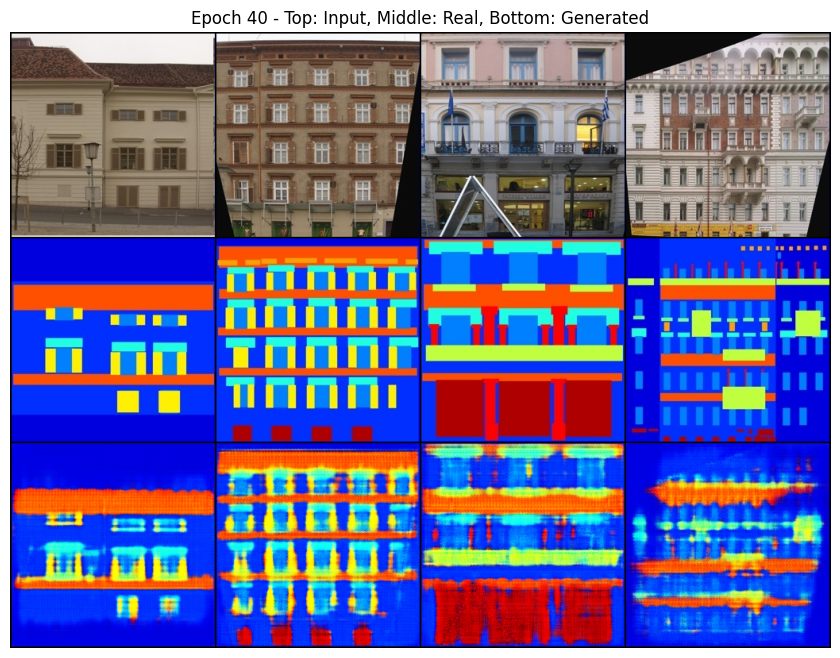

Epoch 40 - D Loss: 0.4092, G Loss: 20.8704


Epoch 50: 100%|██████████| 17/17 [00:10<00:00,  1.63it/s]


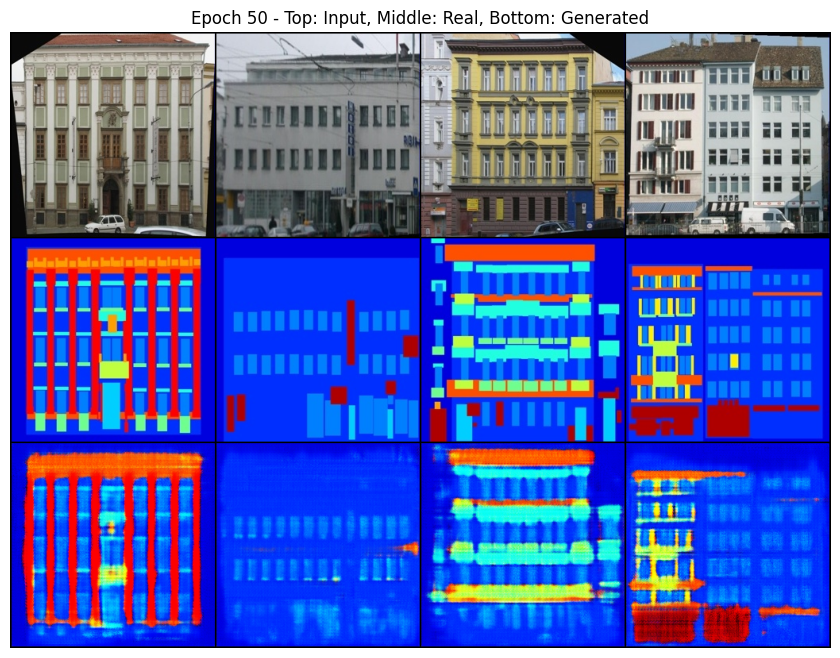

Epoch 50 - D Loss: 0.8944, G Loss: 21.3639


In [ ]:
num_epochs = 50
lambda_L1 = 100

for epoch in range(num_epochs):
    for i, (input_imgs, real_imgs) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}")):
        batch_size = input_imgs.size(0)
        input_imgs = input_imgs.to(device)
        real_imgs = real_imgs.to(device)

        real_labels = torch.ones(batch_size, 1, 30, 30).to(device)
        fake_labels = torch.zeros(batch_size, 1, 30, 30).to(device)

        # Train Discriminator
        optimizer_D.zero_grad()

        real_pred = D(input_imgs, real_imgs)
        d_real_loss = criterion_GAN(real_pred, real_labels)

        fake_imgs = G(input_imgs)
        fake_pred = D(input_imgs, fake_imgs.detach())
        d_fake_loss = criterion_GAN(fake_pred, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) * 0.5
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        fake_pred = D(input_imgs, fake_imgs)
        g_gan_loss = criterion_GAN(fake_pred, real_labels)
        g_l1_loss = criterion_L1(fake_imgs, real_imgs)
        g_loss = g_gan_loss + lambda_L1 * g_l1_loss

        g_loss.backward()
        optimizer_G.step()

    # Show results every 10 epochs
    if (epoch + 1) % 10 == 0:
        G.eval()
        with torch.no_grad():
            test_input, test_real = next(iter(dataloader))
            test_input = test_input[:4].to(device)
            test_real = test_real[:4].to(device)
            test_fake = G(test_input)

            # Denormalize for display
            def denorm(x):
                return x * 0.5 + 0.5

            comparison = torch.cat([
                denorm(test_input.cpu()),
                denorm(test_real.cpu()),
                denorm(test_fake.cpu())
            ], dim=0)

            plt.figure(figsize=(12, 8))
            plt.imshow(np.transpose(vutils.make_grid(comparison, nrow=4, padding=2), (1, 2, 0)))
            plt.title(f'Epoch {epoch+1} - Top: Input, Middle: Real, Bottom: Generated')
            plt.axis('off')
            plt.show()

        G.train()
        print(f'Epoch {epoch+1} - D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}')


In [ ]:
torch.save(G.state_dict(), 'generator.pth')
print("Training completed! Model saved as 'generator.pth'")

Training completed! Model saved as 'generator.pth'
